A EDA do dataset LinkedIn Job Postings mostrou que a base possui 123.849 vagas únicas e 31 colunas originais. Cada vaga é identificada pela coluna `job_id`, que não apresenta duplicatas, tornando-a adequada como chave principal para composição com arquivos complementares.

As colunas `title` e `description` são as mais relevantes para o projeto, pois representam o cargo e a descrição textual da vaga. As descrições possuem, em média, 3.766 caracteres e 523 palavras, o que torna o dataset adequado para técnicas de NLP, como TF-IDF e similaridade por cosseno.

A análise também mostrou que a coluna `skills_desc` possui muitos valores ausentes, com cerca de 98% de dados faltantes. Por isso, a extração de habilidades deve utilizar os arquivos complementares `job_skills.csv` e `skills.csv`, que permitem mapear habilidades por `job_id`.

Também foi possível enriquecer a base principal com informações de empresas, a partir do arquivo `companies.csv`, e com habilidades mapeadas, a partir dos arquivos de skills. A base enriquecida manteve as 123.849 vagas, indicando que a composição não gerou duplicação de registros.

Em relação aos salários, apenas 36.073 vagas possuem alguma informação salarial, o que representa 29,13% da base. Além disso, os valores estão associados a diferentes períodos de pagamento, como anual, horário e mensal. Por esse motivo, a previsão salarial deve ser tratada como uma etapa opcional e posterior, exigindo filtragem e normalização dos dados.

Dessa forma, o dataset LinkedIn Job Postings será utilizado principalmente como catálogo de vagas reais. A coluna `texto_vaga_completo`, criada a partir de título, descrição e skills, será usada nas próximas etapas para comparar o currículo do usuário com as vagas disponíveis e gerar o ranking Top-5 de oportunidades mais aderentes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import kagglehub

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [ ]:
path = kagglehub.dataset_download("arshkon/linkedin-job-postings")

DATASET_PATH = Path(path)

print("Path to dataset files:", DATASET_PATH)
print("A pasta existe?", DATASET_PATH.exists())

100%|██████████| 159M/159M [00:01<00:00, 93.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13
A pasta existe? True


In [ ]:
arquivos = sorted(DATASET_PATH.rglob("*"))

for arquivo in arquivos:
    if arquivo.is_file():
        print(arquivo.relative_to(DATASET_PATH))

companies/companies.csv
companies/company_industries.csv
companies/company_specialities.csv
companies/employee_counts.csv
jobs/benefits.csv
jobs/job_industries.csv
jobs/job_skills.csv
jobs/salaries.csv
mappings/industries.csv
mappings/skills.csv
postings.csv


In [ ]:
caminho_postings = DATASET_PATH / "postings.csv"

if not caminho_postings.exists():
    raise FileNotFoundError("Arquivo postings.csv não encontrado no dataset.")

df_jobs = pd.read_csv(caminho_postings, low_memory=False)

print("Dataset carregado com sucesso.")
print("Formato:", df_jobs.shape)

df_jobs.head()

Dataset carregado com sucesso.
Formato: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high ...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client wit...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine...",1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [ ]:
print("1. Quantas linhas existem?")
print(df_jobs.shape[0])

print("\n2. Quantas colunas existem?")
print(df_jobs.shape[1])

print("\n3. Quais colunas existem?")
for coluna in df_jobs.columns:
    print("-", coluna)

1. Quantas linhas existem?
123849

2. Quantas colunas existem?
31

3. Quais colunas existem?
- job_id
- company_name
- title
- description
- max_salary
- pay_period
- location
- company_id
- views
- med_salary
- min_salary
- formatted_work_type
- applies
- original_listed_time
- remote_allowed
- job_posting_url
- application_url
- application_type
- expiry
- closed_time
- formatted_experience_level
- skills_desc
- listed_time
- posting_domain
- sponsored
- work_type
- currency
- compensation_type
- normalized_salary
- zip_code
- fips


In [ ]:
resumo_colunas = pd.DataFrame({
    "coluna": df_jobs.columns,
    "tipo": df_jobs.dtypes.astype(str).values,
    "qtd_nulos": df_jobs.isna().sum().values,
    "percentual_nulos": (df_jobs.isna().mean().values * 100).round(2),
    "qtd_valores_unicos": df_jobs.nunique(dropna=True).values
})

resumo_colunas.sort_values("percentual_nulos", ascending=False)

,coluna,tipo,qtd_nulos,percentual_nulos,qtd_valores_unicos
19,closed_time,float64,122776,99.13,698
21,skills_desc,object,121410,98.03,2212
9,med_salary,float64,117569,94.93,1417
14,remote_allowed,float64,108603,87.69,1
12,applies,float64,100529,81.17,274
10,min_salary,float64,94056,75.94,4612
4,max_salary,float64,94056,75.94,5321
26,currency,object,87776,70.87,6
27,compensation_type,object,87776,70.87,1
5,pay_period,object,87776,70.87,5


In [ ]:
resumo_colunas = pd.DataFrame({
    "coluna": df_jobs.columns,
    "tipo": df_jobs.dtypes.astype(str).values,
    "qtd_nulos": df_jobs.isna().sum().values,
    "percentual_nulos": (df_jobs.isna().mean().values * 100).round(2),
    "qtd_valores_unicos": df_jobs.nunique(dropna=True).values
})

resumo_colunas.sort_values("percentual_nulos", ascending=False)

,coluna,tipo,qtd_nulos,percentual_nulos,qtd_valores_unicos
19,closed_time,float64,122776,99.13,698
21,skills_desc,object,121410,98.03,2212
9,med_salary,float64,117569,94.93,1417
14,remote_allowed,float64,108603,87.69,1
12,applies,float64,100529,81.17,274
10,min_salary,float64,94056,75.94,4612
4,max_salary,float64,94056,75.94,5321
26,currency,object,87776,70.87,6
27,compensation_type,object,87776,70.87,1
5,pay_period,object,87776,70.87,5


In [ ]:
colunas_importantes = [
    "job_id",
    "company_id",
    "company_name",
    "title",
    "description",
    "max_salary",
    "med_salary",
    "min_salary",
    "pay_period",
    "formatted_work_type",
    "location",
    "remote_allowed",
    "views",
    "applies",
    "job_posting_url",
    "application_url",
    "application_type",
    "formatted_experience_level",
    "skills_desc",
    "listed_time",
    "original_listed_time",
    "work_type",
    "currency",
    "compensation_type"
]

colunas_existentes = [col for col in colunas_importantes if col in df_jobs.columns]
colunas_ausentes = [col for col in colunas_importantes if col not in df_jobs.columns]

print("Colunas importantes encontradas:")
for col in colunas_existentes:
    print("-", col)

print("\nColunas importantes ausentes:")
for col in colunas_ausentes:
    print("-", col)

df_jobs[colunas_existentes].head()

Colunas importantes encontradas:
- job_id
- company_id
- company_name
- title
- description
- max_salary
- med_salary
- min_salary
- pay_period
- formatted_work_type
- location
- remote_allowed
- views
- applies
- job_posting_url
- application_url
- application_type
- formatted_experience_level
- skills_desc
- listed_time
- original_listed_time
- work_type
- currency
- compensation_type

Colunas importantes ausentes:


,job_id,company_id,company_name,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,remote_allowed,views,applies,job_posting_url,application_url,application_type,formatted_experience_level,skills_desc,listed_time,original_listed_time,work_type,currency,compensation_type
0,921716,2774458.0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,20.0,NaN,17.0,HOURLY,Full-time,"Princeton, NJ",NaN,20.0,2.0,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...,1.713398e+12,1.713398e+12,FULL_TIME,USD,BASE_SALARY
1,1829192,NaN,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...",50.0,NaN,30.0,HOURLY,Full-time,"Fort Collins, CO",NaN,1.0,NaN,https://www.linkedin.com/jobs/view/1829192/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,NaN,NaN,1.712858e+12,1.712858e+12,FULL_TIME,USD,BASE_SALARY
2,10998357,64896719.0,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,65000.0,NaN,45000.0,YEARLY,Full-time,"Cincinnati, OH",NaN,8.0,NaN,https://www.linkedin.com/jobs/view/10998357/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high ...,1.713278e+12,1.713278e+12,FULL_TIME,USD,BASE_SALARY
3,23221523,766262.0,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client wit...,175000.0,NaN,140000.0,YEARLY,Full-time,"New Hyde Park, NY",NaN,16.0,NaN,https://www.linkedin.com/jobs/view/23221523/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,NaN,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine...",1.712896e+12,1.712896e+12,FULL_TIME,USD,BASE_SALARY
4,35982263,NaN,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with...,80000.0,NaN,60000.0,YEARLY,Full-time,"Burlington, IA",NaN,3.0,NaN,https://www.linkedin.com/jobs/view/35982263/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,NaN,NaN,1.713452e+12,1.713452e+12,FULL_TIME,USD,BASE_SALARY


In [ ]:
coluna_id_vaga = "job_id"
coluna_titulo = "title"
coluna_descricao = "description"
coluna_empresa = "company_name" if "company_name" in df_jobs.columns else "company_id"
coluna_localizacao = "location"

print("Coluna que representa o ID da vaga:", coluna_id_vaga)
print("Coluna que representa o título/cargo da vaga:", coluna_titulo)
print("Coluna que representa a descrição da vaga:", coluna_descricao)
print("Coluna que representa a empresa:", coluna_empresa)
print("Coluna que representa a localização:", coluna_localizacao)

Coluna que representa o ID da vaga: job_id
Coluna que representa o título/cargo da vaga: title
Coluna que representa a descrição da vaga: description
Coluna que representa a empresa: company_name
Coluna que representa a localização: location


In [ ]:
titulos_vazios = df_jobs["title"].isna().sum() + (df_jobs["title"].fillna("").astype(str).str.strip() == "").sum()
descricoes_vazias = df_jobs["description"].isna().sum() + (df_jobs["description"].fillna("").astype(str).str.strip() == "").sum()

print("Títulos vazios:", titulos_vazios)
print("Descrições vazias:", descricoes_vazias)

if "skills_desc" in df_jobs.columns:
    skills_vazias = df_jobs["skills_desc"].isna().sum() + (df_jobs["skills_desc"].fillna("").astype(str).str.strip() == "").sum()
    print("Skills_desc vazias:", skills_vazias)

Títulos vazios: 0
Descrições vazias: 14
Skills_desc vazias: 242820


In [ ]:
df_jobs["tamanho_descricao"] = df_jobs["description"].fillna("").astype(str).str.len()
df_jobs["qtd_palavras_descricao"] = df_jobs["description"].fillna("").astype(str).str.split().str.len()

print("Tamanho médio da descrição em caracteres:")
print(round(df_jobs["tamanho_descricao"].mean(), 2))

print("\nQuantidade média de palavras na descrição:")
print(round(df_jobs["qtd_palavras_descricao"].mean(), 2))

df_jobs[["title", "description", "tamanho_descricao", "qtd_palavras_descricao"]].head()

Tamanho médio da descrição em caracteres:
3766.25

Quantidade média de palavras na descrição:
523.03


,title,description,tamanho_descricao,qtd_palavras_descricao
0,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,2526,358
1,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...",3560,492
2,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,462,66
3,Senior Elder Law / Trusts and Estates Associate Attorney,Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client wit...,1599,209
4,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with...,232,36


title
Sales Manager                      673
Customer Service Representative    373
Project Manager                    354
Administrative Assistant           254
Senior Accountant                  238
Executive Assistant                228
Salesperson                        211
Registered Nurse                   210
Receptionist                       204
Staff Accountant                   200
Account Executive                  195
Retail Sales Associate             190
Sales Associate                    189
Software Engineer                  181
Controller                         175
Account Manager                    171
Store Manager                      166
Senior Software Engineer           162
Assistant Manager                  161
ASSISTANT STORE MANAGER            161
Name: count, dtype: int64


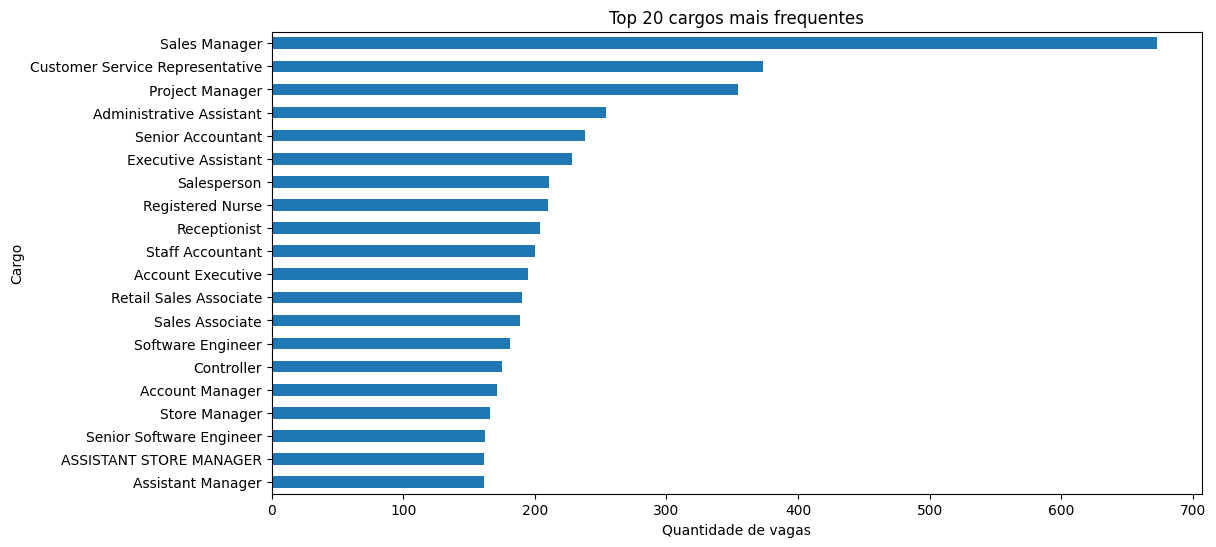

In [ ]:
top_cargos = df_jobs["title"].value_counts().head(20)

print(top_cargos)

plt.figure(figsize=(12, 6))
top_cargos.sort_values().plot(kind="barh")
plt.title("Top 20 cargos mais frequentes")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Cargo")
plt.show()

location
United States                      8125
New York, NY                       2756
Chicago, IL                        1834
Houston, TX                        1762
Dallas, TX                         1383
Atlanta, GA                        1363
Boston, MA                         1176
Austin, TX                         1083
Charlotte, NC                      1075
Phoenix, AZ                        1059
Washington, DC                      985
Los Angeles, CA                     972
San Francisco, CA                   884
New York City Metropolitan Area     837
Seattle, WA                         818
San Diego, CA                       790
Denver, CO                          787
Philadelphia, PA                    711
Tampa, FL                           659
Miami, FL                           643
Name: count, dtype: int64


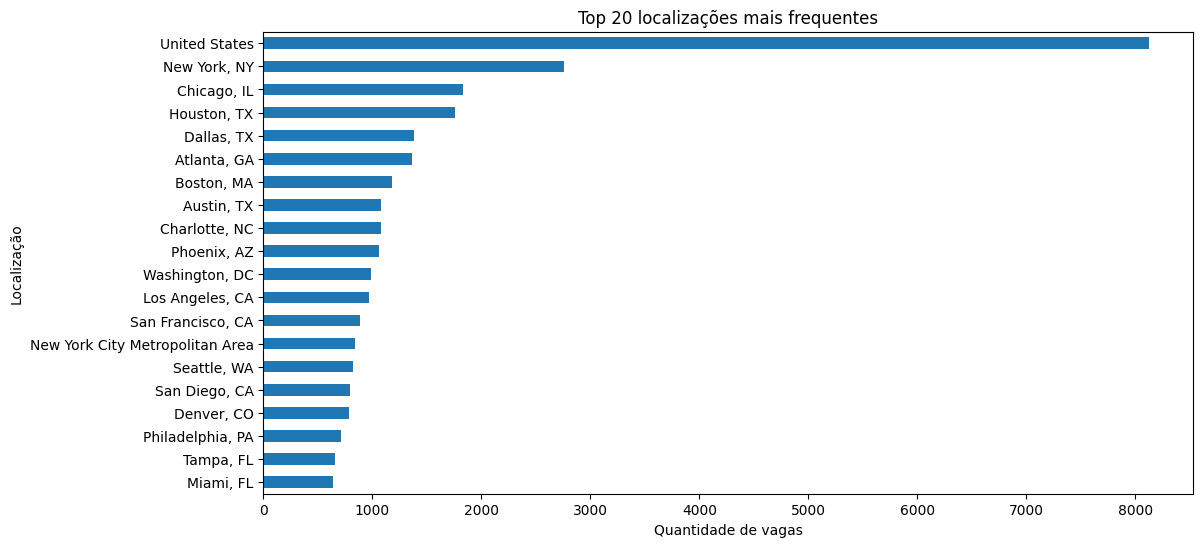

In [ ]:
top_localizacoes = df_jobs["location"].value_counts().head(20)

print(top_localizacoes)

plt.figure(figsize=(12, 6))
top_localizacoes.sort_values().plot(kind="barh")
plt.title("Top 20 localizações mais frequentes")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Localização")
plt.show()

formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64


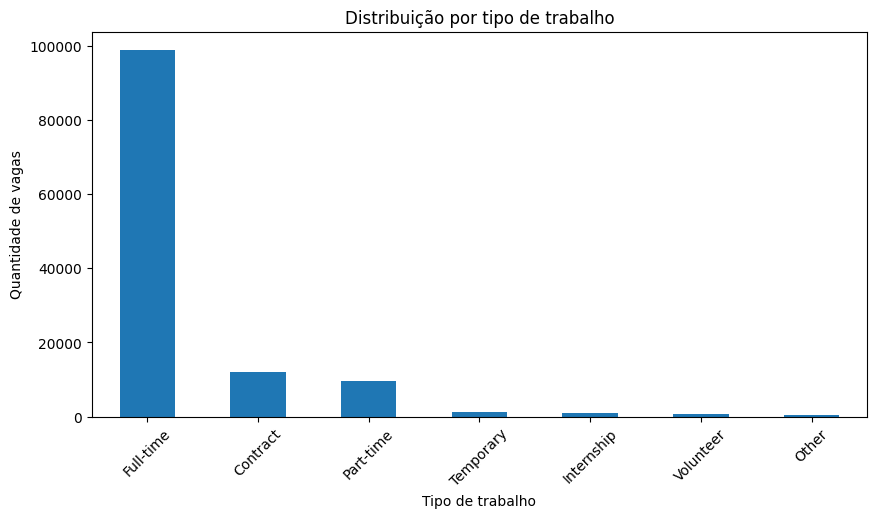

In [ ]:
if "formatted_work_type" in df_jobs.columns:
    tipo_trabalho = df_jobs["formatted_work_type"].value_counts(dropna=False)

    print(tipo_trabalho)

    plt.figure(figsize=(10, 5))
    tipo_trabalho.plot(kind="bar")
    plt.title("Distribuição por tipo de trabalho")
    plt.xlabel("Tipo de trabalho")
    plt.ylabel("Quantidade de vagas")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Coluna formatted_work_type não encontrada.")

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64


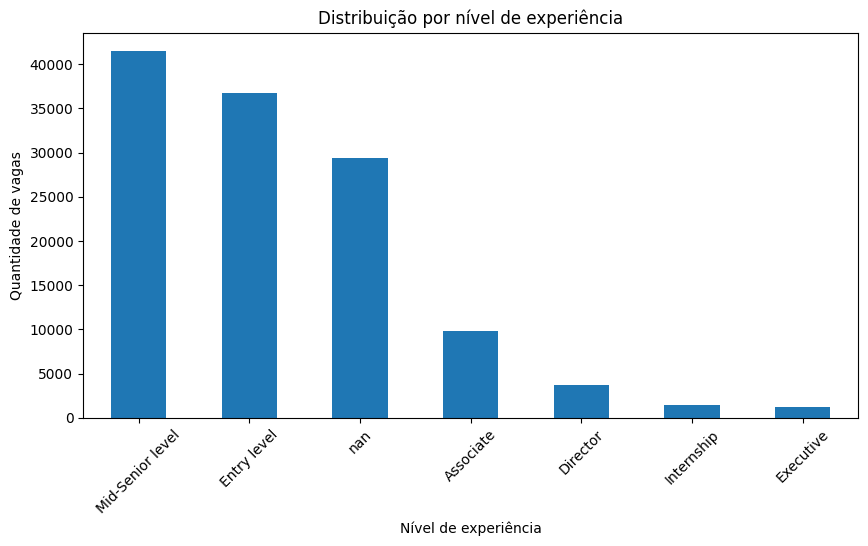

In [ ]:
if "formatted_experience_level" in df_jobs.columns:
    experiencia = df_jobs["formatted_experience_level"].value_counts(dropna=False)

    print(experiencia)

    plt.figure(figsize=(10, 5))
    experiencia.plot(kind="bar")
    plt.title("Distribuição por nível de experiência")
    plt.xlabel("Nível de experiência")
    plt.ylabel("Quantidade de vagas")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Coluna formatted_experience_level não encontrada.")

remote_allowed
NaN    108603
1.0     15246
Name: count, dtype: int64


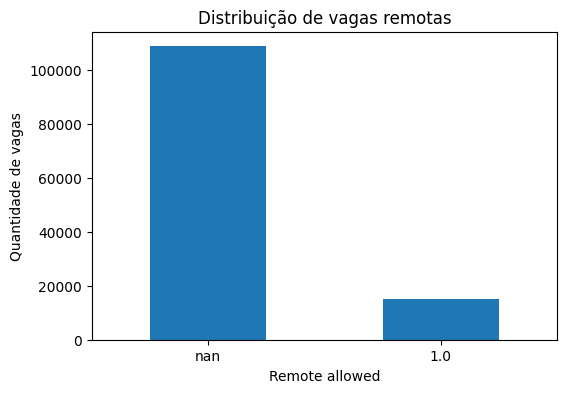

In [ ]:
if "remote_allowed" in df_jobs.columns:
    remoto = df_jobs["remote_allowed"].value_counts(dropna=False)

    print(remoto)

    plt.figure(figsize=(6, 4))
    remoto.plot(kind="bar")
    plt.title("Distribuição de vagas remotas")
    plt.xlabel("Remote allowed")
    plt.ylabel("Quantidade de vagas")
    plt.xticks(rotation=0)
    plt.show()
else:
    print("Coluna remote_allowed não encontrada.")

In [ ]:
colunas_salario = ["min_salary", "med_salary", "max_salary"]
colunas_salario_existentes = [col for col in colunas_salario if col in df_jobs.columns]

for col in colunas_salario_existentes:
    df_jobs[col] = pd.to_numeric(df_jobs[col], errors="coerce")

print("Colunas de salário encontradas:")
print(colunas_salario_existentes)

df_jobs["possui_salario"] = df_jobs[colunas_salario_existentes].notna().any(axis=1)

qtd_com_salario = df_jobs["possui_salario"].sum()
qtd_sem_salario = (~df_jobs["possui_salario"]).sum()
percentual_com_salario = qtd_com_salario / len(df_jobs) * 100

print("\nVagas com alguma informação salarial:", qtd_com_salario)
print("Vagas sem informação salarial:", qtd_sem_salario)
print(f"Percentual com salário: {percentual_com_salario:.2f}%")

df_jobs[colunas_salario_existentes].describe()

Colunas de salário encontradas:
['min_salary', 'med_salary', 'max_salary']

Vagas com alguma informação salarial: 36073
Vagas sem informação salarial: 87776
Percentual com salário: 29.13%


,min_salary,med_salary,max_salary
count,2.979300e+04,6280.000000,2.979300e+04
mean,6.491085e+04,22015.619876,9.193942e+04
std,4.959738e+05,52255.873846,7.011101e+05
min,1.000000e+00,0.000000,1.000000e+00
25%,3.700000e+01,18.940000,4.828000e+01
50%,6.000000e+04,25.500000,8.000000e+04
75%,1.000000e+05,2510.500000,1.400000e+05
max,8.500000e+07,750000.000000,1.200000e+08


pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64


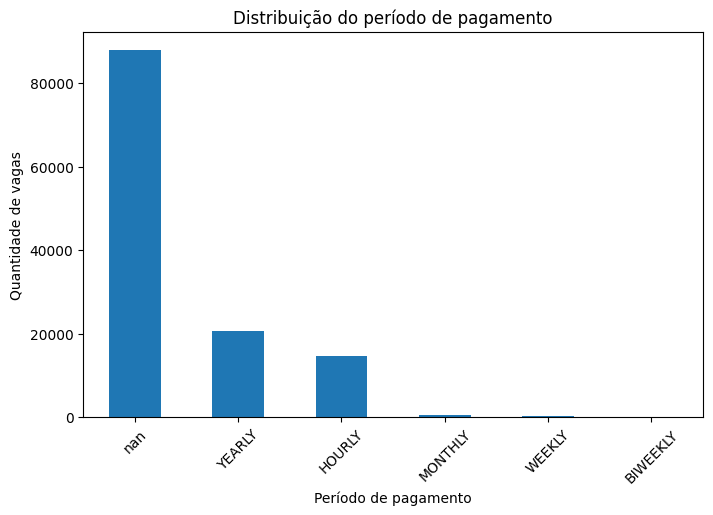

In [ ]:
if "pay_period" in df_jobs.columns:
    periodo_pagamento = df_jobs["pay_period"].value_counts(dropna=False)

    print(periodo_pagamento)

    plt.figure(figsize=(8, 5))
    periodo_pagamento.plot(kind="bar")
    plt.title("Distribuição do período de pagamento")
    plt.xlabel("Período de pagamento")
    plt.ylabel("Quantidade de vagas")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Coluna pay_period não encontrada.")

In [ ]:
qtd_job_id_unicos = df_jobs["job_id"].nunique()
qtd_duplicados = df_jobs["job_id"].duplicated().sum()

print("Quantidade de job_id únicos:", qtd_job_id_unicos)
print("Quantidade de job_id duplicados:", qtd_duplicados)
print("Total de linhas:", len(df_jobs))

Quantidade de job_id únicos: 123849
Quantidade de job_id duplicados: 0
Total de linhas: 123849


In [ ]:
def carregar_csv_se_existir(nome_arquivo):
    caminhos = list(DATASET_PATH.rglob(nome_arquivo))

    if len(caminhos) == 0:
        print(f"Arquivo não encontrado: {nome_arquivo}")
        return None

    caminho = caminhos[0]
    print(f"Carregando {nome_arquivo}: {caminho.relative_to(DATASET_PATH)}")

    return pd.read_csv(caminho, low_memory=False)


df_companies = carregar_csv_se_existir("companies.csv")
df_employee_counts = carregar_csv_se_existir("employee_counts.csv")
df_benefits = carregar_csv_se_existir("benefits.csv")
df_job_skills = carregar_csv_se_existir("job_skills.csv")
df_skills = carregar_csv_se_existir("skills.csv")
df_job_industries = carregar_csv_se_existir("job_industries.csv")
df_industries = carregar_csv_se_existir("industries.csv")

Carregando companies.csv: companies/companies.csv
Carregando employee_counts.csv: companies/employee_counts.csv
Carregando benefits.csv: jobs/benefits.csv
Carregando job_skills.csv: jobs/job_skills.csv
Carregando skills.csv: mappings/skills.csv
Carregando job_industries.csv: jobs/job_industries.csv
Carregando industries.csv: mappings/industries.csv


In [ ]:
datasets_auxiliares = {
    "companies": df_companies,
    "employee_counts": df_employee_counts,
    "benefits": df_benefits,
    "job_skills": df_job_skills,
    "skills": df_skills,
    "job_industries": df_job_industries,
    "industries": df_industries
}

resumo_auxiliares = []

for nome, df_aux in datasets_auxiliares.items():
    if df_aux is not None:
        resumo_auxiliares.append({
            "dataset": nome,
            "linhas": df_aux.shape[0],
            "colunas": df_aux.shape[1],
            "nomes_colunas": df_aux.columns.tolist()
        })

resumo_auxiliares = pd.DataFrame(resumo_auxiliares)

resumo_auxiliares

,dataset,linhas,colunas,nomes_colunas
0,companies,24473,10,"[company_id, name, description, company_size, state, country, city, zip_code, address, url]"
1,employee_counts,35787,4,"[company_id, employee_count, follower_count, time_recorded]"
2,benefits,67943,3,"[job_id, inferred, type]"
3,job_skills,213768,2,"[job_id, skill_abr]"
4,skills,35,2,"[skill_abr, skill_name]"
5,job_industries,164808,2,"[job_id, industry_id]"
6,industries,422,2,"[industry_id, industry_name]"


In [ ]:
datasets_auxiliares = {
    "companies": df_companies,
    "employee_counts": df_employee_counts,
    "benefits": df_benefits,
    "job_skills": df_job_skills,
    "skills": df_skills,
    "job_industries": df_job_industries,
    "industries": df_industries
}

resumo_auxiliares = []

for nome, df_aux in datasets_auxiliares.items():
    if df_aux is not None:
        resumo_auxiliares.append({
            "dataset": nome,
            "linhas": df_aux.shape[0],
            "colunas": df_aux.shape[1],
            "nomes_colunas": df_aux.columns.tolist()
        })

resumo_auxiliares = pd.DataFrame(resumo_auxiliares)

resumo_auxiliares

,dataset,linhas,colunas,nomes_colunas
0,companies,24473,10,"[company_id, name, description, company_size, state, country, city, zip_code, address, url]"
1,employee_counts,35787,4,"[company_id, employee_count, follower_count, time_recorded]"
2,benefits,67943,3,"[job_id, inferred, type]"
3,job_skills,213768,2,"[job_id, skill_abr]"
4,skills,35,2,"[skill_abr, skill_name]"
5,job_industries,164808,2,"[job_id, industry_id]"
6,industries,422,2,"[industry_id, industry_name]"


In [ ]:
if df_companies is not None:
    print("Formato da base de empresas:", df_companies.shape)
    display(df_companies.head())

    print("\nColunas da base de empresas:")
    for coluna in df_companies.columns:
        print("-", coluna)
else:
    print("Base companies.csv não encontrada.")

Formato da base de empresas: (24473, 10)


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We create as technologists, developers, and engineers. We create with our p...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,"Every day millions of people feel the impact of our intelligent devices, advanced analytics and artificial intellige...",7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,"Official LinkedIn of Hewlett Packard Enterprise, the global edge-to-cloud company. Sharing our passion and purpose t...",7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packard-enterprise
3,1028,Oracle,We’re a cloud technology company that provides organizations around the world with computing infrastructure and soft...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,"Accenture is a leading global professional services company that helps the world’s leading businesses, governments a...",7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture



Colunas da base de empresas:
- company_id
- name
- description
- company_size
- state
- country
- city
- zip_code
- address
- url


In [ ]:
if df_job_skills is not None:
    print("Formato da base job_skills:", df_job_skills.shape)
    display(df_job_skills.head())

    print("\nColunas de job_skills:")
    for coluna in df_job_skills.columns:
        print("-", coluna)

if df_skills is not None:
    print("\nFormato da base skills:", df_skills.shape)
    display(df_skills.head())

    print("\nColunas de skills:")
    for coluna in df_skills.columns:
        print("-", coluna)

Formato da base job_skills: (213768, 2)


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN



Colunas de job_skills:
- job_id
- skill_abr

Formato da base skills: (35, 2)


,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution



Colunas de skills:
- skill_abr
- skill_name


In [ ]:
df_jobs_empresas = df_jobs.copy()

if df_companies is not None and "company_id" in df_jobs_empresas.columns and "company_id" in df_companies.columns:
    colunas_empresa = [
        "company_id",
        "name",
        "description",
        "company_size",
        "country",
        "state",
        "city"
    ]

    colunas_empresa_existentes = [col for col in colunas_empresa if col in df_companies.columns]

    df_companies_reduzido = df_companies[colunas_empresa_existentes].copy()

    df_jobs_empresas = df_jobs_empresas.merge(
        df_companies_reduzido,
        on="company_id",
        how="left",
        suffixes=("", "_empresa")
    )

    print("Formato após juntar vagas com empresas:", df_jobs_empresas.shape)
    display(df_jobs_empresas.head())
else:
    print("Não foi possível juntar com empresas.")

Formato após juntar vagas com empresas: (123849, 40)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,tamanho_descricao,qtd_palavras_descricao,possui_salario,name,description_empresa,company_size,country,state,city
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,2526,358,True,Corcoran Sawyer Smith,"With years of experience helping local buyers and sellers just like yourself, we know how to locate the finest prope...",2.0,US,NJ,Jersey City
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0,3560,492,True,NaN,NaN,NaN,NaN,NaN,NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high ...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,462,66,True,The National Exemplar,"In April of 1983, The National Exemplar began operation in the Mariemont, Ohio landmark, the Mariemont Inn. The Inn ...",1.0,US,Ohio,Mariemont
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client wit...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine...",1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,1599,209,True,"Abrams Fensterman, LLP","Abrams Fensterman, LLP is a full-service law firm that provides exceptional legal advice, personalized representatio...",2.0,US,New York,Lake Success
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0,232,36,True,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_skills_por_vaga = None

if df_job_skills is not None:
    df_job_skills_tratado = df_job_skills.copy()

    if df_skills is not None:
        if "skill_abr" in df_job_skills_tratado.columns and "skill_abr" in df_skills.columns:
            df_job_skills_tratado = df_job_skills_tratado.merge(
                df_skills,
                on="skill_abr",
                how="left"
            )

    print("Colunas disponíveis após possível merge:")
    print(df_job_skills_tratado.columns.tolist())

    if "skill_name" in df_job_skills_tratado.columns:
        coluna_skill = "skill_name"
    elif "skill_abr" in df_job_skills_tratado.columns:
        coluna_skill = "skill_abr"
    elif "skill" in df_job_skills_tratado.columns:
        coluna_skill = "skill"
    else:
        coluna_skill = None

    if coluna_skill is not None and "job_id" in df_job_skills_tratado.columns:
        df_skills_por_vaga = (
            df_job_skills_tratado
            .dropna(subset=["job_id", coluna_skill])
            .groupby("job_id")[coluna_skill]
            .apply(lambda valores: ", ".join(sorted(set(map(str, valores)))))
            .reset_index()
            .rename(columns={coluna_skill: "skills_mapeadas"})
        )

        print("Skills agregadas por vaga:")
        display(df_skills_por_vaga.head())
        print("Formato:", df_skills_por_vaga.shape)
    else:
        print("Não foi possível identificar uma coluna de skill.")
else:
    print("Base job_skills.csv não encontrada.")

Colunas disponíveis após possível merge:
['job_id', 'skill_abr', 'skill_name']
Skills agregadas por vaga:


,job_id,skills_mapeadas
0,921716,"Marketing, Sales"
1,1218575,Health Care Provider
2,1829192,Health Care Provider
3,2264355,"Art/Creative, Design, Information Technology"
4,10998357,"Management, Manufacturing"


Formato: (126807, 2)


In [ ]:
df_jobs_enriquecido = df_jobs_empresas.copy()

if df_skills_por_vaga is not None and "job_id" in df_jobs_enriquecido.columns:
    df_jobs_enriquecido = df_jobs_enriquecido.merge(
        df_skills_por_vaga,
        on="job_id",
        how="left"
    )

print("Formato da base enriquecida:", df_jobs_enriquecido.shape)

df_jobs_enriquecido.head()

Formato da base enriquecida: (123849, 41)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,tamanho_descricao,qtd_palavras_descricao,possui_salario,name,description_empresa,company_size,country,state,city,skills_mapeadas
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,2526,358,True,Corcoran Sawyer Smith,"With years of experience helping local buyers and sellers just like yourself, we know how to locate the finest prope...",2.0,US,NJ,Jersey City,"Marketing, Sales"
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0,3560,492,True,NaN,NaN,NaN,NaN,NaN,NaN,Health Care Provider
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high ...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,462,66,True,The National Exemplar,"In April of 1983, The National Exemplar began operation in the Mariemont, Ohio landmark, the Mariemont Inn. The Inn ...",1.0,US,Ohio,Mariemont,"Management, Manufacturing"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client wit...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine...",1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,1599,209,True,"Abrams Fensterman, LLP","Abrams Fensterman, LLP is a full-service law firm that provides exceptional legal advice, personalized representatio...",2.0,US,New York,Lake Success,Other
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0,232,36,True,NaN,NaN,NaN,NaN,NaN,NaN,Information Technology


In [ ]:
def juntar_textos(linha, colunas):
    partes = []

    for coluna in colunas:
        if coluna in linha.index and pd.notna(linha[coluna]):
            texto = str(linha[coluna]).strip()

            if texto != "":
                partes.append(texto)

    return " ".join(partes)


colunas_texto_vaga = []

for coluna in ["title", "description", "skills_desc", "skills_mapeadas"]:
    if coluna in df_jobs_enriquecido.columns:
        colunas_texto_vaga.append(coluna)

print("Colunas usadas para criar o texto completo da vaga:")
print(colunas_texto_vaga)

df_jobs_enriquecido["texto_vaga_completo"] = df_jobs_enriquecido.apply(
    lambda linha: juntar_textos(linha, colunas_texto_vaga),
    axis=1
)

df_jobs_enriquecido[["title", "texto_vaga_completo"]].head()

Colunas usadas para criar o texto completo da vaga:
['title', 'description', 'skills_desc', 'skills_mapeadas']


,title,texto_vaga_completo
0,Marketing Coordinator,Marketing Coordinator Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing...
1,Mental Health Therapist/Counselor,"Mental Health Therapist/Counselor At Aspen Therapy and Wellness , we are committed to serving clients with best prac..."
2,Assitant Restaurant Manager,Assitant Restaurant Manager The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe...
3,Senior Elder Law / Trusts and Estates Associate Attorney,Senior Elder Law / Trusts and Estates Associate Attorney Senior Associate Attorney - Elder Law / Trusts and Estates ...
4,Service Technician,Service Technician Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 y...


In [ ]:
print("Resumo final da EDA — LinkedIn Job Postings")
print("=" * 60)

print("\n1. Quantidade de linhas:")
print(df_jobs.shape[0])

print("\n2. Quantidade de colunas:")
print(df_jobs.shape[1])

print("\n3. Coluna que representa o cargo:")
print("title")

print("\n4. Coluna que representa a descrição da vaga:")
print("description")

print("\n5. Coluna que representa a empresa:")
print("company_name" if "company_name" in df_jobs.columns else "company_id")

print("\n6. Colunas de salário disponíveis:")
print(colunas_salario_existentes)

print("\n7. Quantidade de vagas com salário:")
print(qtd_com_salario)

print("\n8. Percentual de vagas com salário:")
print(f"{percentual_com_salario:.2f}%")

print("\n9. Colunas usadas para texto da vaga:")
print(colunas_texto_vaga)

print("\n10. Como esse dataset será usado?")
print(
    "Será usado como catálogo de vagas reais. "
    "Cada vaga terá título, descrição, empresa, localização, informações salariais e, quando disponível, skills. "
    "Depois, o currículo do usuário será comparado com o texto completo dessas vagas para gerar o ranking Top-5."
)

Resumo final da EDA — LinkedIn Job Postings

1. Quantidade de linhas:
123849

2. Quantidade de colunas:
34

3. Coluna que representa o cargo:
title

4. Coluna que representa a descrição da vaga:
description

5. Coluna que representa a empresa:
company_name

6. Colunas de salário disponíveis:
['min_salary', 'med_salary', 'max_salary']

7. Quantidade de vagas com salário:
36073

8. Percentual de vagas com salário:
29.13%

9. Colunas usadas para texto da vaga:
['title', 'description', 'skills_desc', 'skills_mapeadas']

10. Como esse dataset será usado?
Será usado como catálogo de vagas reais. Cada vaga terá título, descrição, empresa, localização, informações salariais e, quando disponível, skills. Depois, o currículo do usuário será comparado com o texto completo dessas vagas para gerar o ranking Top-5.
